# Step 3 Imputation of missing data
- Estimate missing values
- Reliability of imputed values 
- Outliers in the data

**Dataset 1 Trending Beauty Products**

Source: https://www.kaggle.com/datasets/waqi786/most-used-beauty-cosmetics-products-in-the-world/data

In [19]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

In [2]:
beauty_products_data = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/beauty_products.csv')
not_cruelty_free_brands = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/brands_that_animal_test.csv')
cruelty_free_brands = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/cruelty_free_brands.csv')
toxic_chemicals_list = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/toxic_chemicals_in_products.csv')

In [3]:
beauty_products_data

,Product_Name,Brand,Category,Usage_Frequency,Price_USD,Rating,Number_of_Reviews,Product_Size,Skin_Type,Gender_Target,Packaging_Type,Main_Ingredient,Cruelty_Free,Country_of_Origin
0,Ultra Face Mask,Drunk Elephant,Blush,Weekly,67.85,1.4,686,30ml,Sensitive,Female,Tube,Retinol,False,Australia
1,Ultra Lipstick,Laura Mercier,Makeup Remover,Occasional,116.43,4.2,5483,250ml,Dry,Unisex,Bottle,Shea Butter,False,UK
2,Ultra Serum,Natasha Denona,Highlighter,Daily,90.84,1.6,5039,100ml,Sensitive,Male,Compact,Aloe Vera,True,Italy
3,Divine Serum,Ilia Beauty,Face Mask,Occasional,55.17,3.2,6202,250ml,Normal,Male,Tube,Glycerin,True,South Korea
4,Super Foundation,Charlotte Tilbury,Highlighter,Occasional,140.56,1.7,297,100ml,Oily,Female,Compact,Glycerin,False,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,Magic Eyeliner,Patrick Ta,Face Mask,Daily,131.64,2.8,1470,250ml,Sensitive,Unisex,Tube,Aloe Vera,True,Italy
14996,Perfect Powder,Farsali,Serum,Weekly,76.35,2.1,7652,250ml,Dry,Unisex,Jar,Salicylic Acid,True,USA
14997,Magic Serum,Kiehl’s,Highlighter,Occasional,65.37,4.2,811,30ml,Combination,Unisex,Jar,Shea Butter,False,South Korea
14998,Magic Mascara,Perricone MD,Powder,Weekly,59.93,4.8,5482,250ml,Dry,Male,Jar,Aloe Vera,True,USA


**Describe the Data**
- Checking numerical fields
- Checking for unique brand names

In [9]:
summary = beauty_products_data.describe()
print(summary)

          Price_USD        Rating  Number_of_Reviews
count  15000.000000  15000.000000       15000.000000
mean      80.134108      3.002327        5014.231333
std       40.402983      1.168029        2855.665464
min       10.000000      1.000000          52.000000
25%       45.480000      2.000000        2562.000000
50%       80.040000      3.000000        5002.000000
75%      114.760000      4.000000        7497.000000
max      149.990000      5.000000       10000.000000


In [10]:
print("Product Name" + beauty_products_data.Product_Name.unique())

['Product NameUltra Face Mask' 'Product NameUltra Lipstick'
 'Product NameUltra Serum' 'Product NameDivine Serum'
 'Product NameSuper Foundation' 'Product NameSuper Eye Shadow'
 'Product NameSuper Lip Gloss' 'Product NameUltra Cleanser'
 'Product NameMagic Highlighter' 'Product NamePerfect Bronzer'
 'Product NameUltra Moisturizer' 'Product NameDivine CC Cream'
 'Product NameUltra Setting Spray' 'Product NameDivine Primer'
 'Product NameDivine Exfoliator' 'Product NamePerfect Blush'
 'Product NamePerfect Highlighter' 'Product NameSuper Cleanser'
 'Product NameUltra Face Oil' 'Product NameDivine Lip Gloss'
 'Product NameDivine Foundation' 'Product NameDivine Cleanser'
 'Product NamePerfect Eyeliner' 'Product NameSuper Serum'
 'Product NameDivine Setting Spray' 'Product NameMagic Eye Shadow'
 'Product NameUltra Exfoliator' 'Product NameMagic Lip Liner'
 'Product NameSuper Makeup Remover' 'Product NamePerfect BB Cream'
 'Product NameMagic BB Cream' 'Product NameSuper Lip Liner'
 'Product N

In [11]:
print("Brand Name" + beauty_products_data.Brand.unique())


['Brand NameDrunk Elephant' 'Brand NameLaura Mercier'
 'Brand NameNatasha Denona' 'Brand NameIlia Beauty'
 'Brand NameCharlotte Tilbury' 'Brand NameDanessa Myricks'
 'Brand NameBourjois' 'Brand NameIT Cosmetics' 'Brand NameFenty Beauty'
 'Brand NameSisley' 'Brand NameJuvia’s Place' 'Brand NameNARS'
 'Brand NameColourPop' 'Brand NameHuda Beauty' 'Brand NameTatcha'
 'Brand NameKiehl’s' 'Brand NameTarte' 'Brand NameGlossier'
 'Brand NameMake Up For Ever' 'Brand NameAnastasia Beverly Hills'
 'Brand NameE.l.f.' 'Brand NameHourglass' 'Brand NamePat McGrath Labs'
 'Brand NameToo Faced' 'Brand NamePerricone MD' 'Brand NameRMS Beauty'
 'Brand NameUrban Decay' 'Brand NameRare Beauty' 'Brand NameBecca'
 'Brand NamePatrick Ta' 'Brand NameShiseido' 'Brand NameKylie Cosmetics'
 'Brand NameBite Beauty' 'Brand NameYves Saint Laurent'
 'Brand NameBobby Brown' 'Brand NameFarsali' 'Brand NameMorphe'
 'Brand NameMilk Makeup' 'Brand NameClinique' 'Brand NameKVD Beauty']


**Check if there are any missing values in Dataset 1**

There are no missing values in Dataset1

In [17]:
print(beauty_products_data.isnull().sum())

Product_Name         0
Brand                0
Category             0
Usage_Frequency      0
Price_USD            0
Rating               0
Number_of_Reviews    0
Product_Size         0
Skin_Type            0
Gender_Target        0
Packaging_Type       0
Main_Ingredient      0
Cruelty_Free         0
Country_of_Origin    0
dtype: int64


**Check for outliers in Dataset 1 for numerical variables**

**Price**

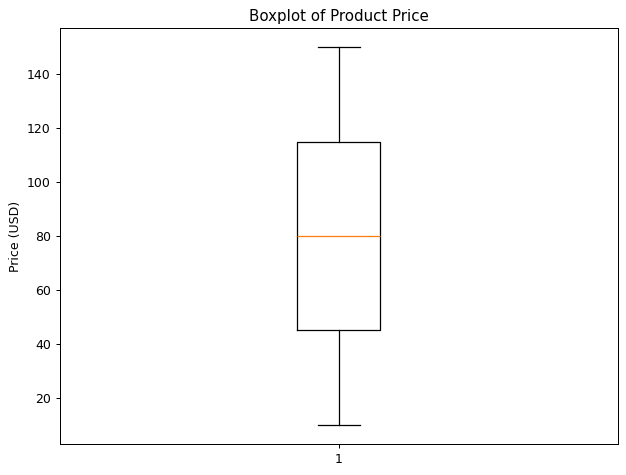

In [22]:
figure(num=None, figsize=(8,6), dpi= 90, facecolor= 'w', edgecolor = 'k')
plt.boxplot(beauty_products_data.Price_USD)
plt.title("Boxplot of Product Price")
plt.ylabel("Price (USD)")
plt.show()

**Number of Reviews**

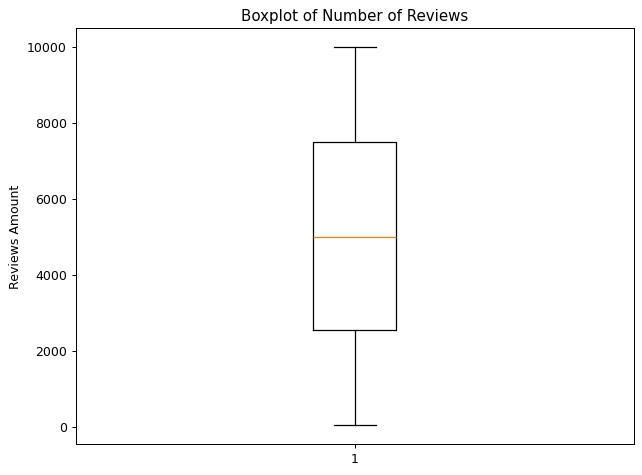

In [24]:
figure(num=None, figsize=(8,6), dpi= 90, facecolor= 'w', edgecolor = 'k')
plt.boxplot(beauty_products_data.Number_of_Reviews)
plt.title("Boxplot of Number of Reviews")
plt.ylabel("Reviews Amount")
plt.show()

Don't need to check for missing values for datasets 2 and 3 

In [4]:
not_cruelty_free_brands

,Unnamed: 0,Brand Name
0,0,Acuvue (Johnson & Johnson)
1,1,Aim (Church & Dwight)
2,2,Air Wick (Reckitt Benckiser)
3,3,Algenist
4,4,Always (Procter & Gamble)
...,...,...
265,265,Windex (S.C. Johnson)
266,266,Woolite (Reckitt Benckiser)
267,267,Xtra (Church & Dwight)
268,268,Zegna


In [5]:
cruelty_free_brands

,Unnamed: 0,Brand Name
0,0,A Good Fur Day
1,1,A.P. CHEM
2,2,A Perfume Organic
3,3,A Touch of Class Beauty
4,4,A Wild Soap Bar
...,...,...
6323,6323,Zoygirl (Zoycare Hygiene)
6324,6324,Zue Beauty
6325,6325,Zuii Organic
6326,6326,Zuzu Cosmetics


**Dataset 4 Toxic Chemicals List**

In [6]:
toxic_chemicals_list

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,6/17/2009,8/28/2013,2/1/2011,7/9/2009,7/9/2009,NaN,1
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),7/1/2009,7/1/2009,NaN,7/1/2009,7/1/2009,NaN,2
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,7/1/2009,7/1/2009,NaN,7/2/2009,7/2/2009,NaN,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,7/9/2009,8/28/2013,NaN,7/9/2009,7/9/2009,NaN,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,7/9/2009,8/28/2013,2/1/2011,7/9/2009,7/9/2009,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114630,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65001.0,Rosa Soft,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68059,Titanium dioxide,6/19/2020,6/19/2020,NaN,6/19/2020,6/19/2020,NaN,1
114631,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65002.0,Malva Spirit,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68060,Titanium dioxide,6/19/2020,6/19/2020,NaN,6/19/2020,6/19/2020,NaN,1
114632,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65003.0,Rojo Fashion,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68061,Titanium dioxide,6/19/2020,6/19/2020,NaN,6/19/2020,6/19/2020,NaN,1
114633,41523,HYDRA-LIP TRANSLUCENT COLOR LIPSTICK,65004.0,Terra Mystic,1259,"Yanbal USA, Inc",YANBAL,44,Makeup Products (non-permanent),53,...,13463-67-7,68062,Titanium dioxide,6/19/2020,6/19/2020,NaN,6/19/2020,6/19/2020,NaN,1


In [25]:
print(beauty_products_data.isnull().sum())

Product_Name         0
Brand                0
Category             0
Usage_Frequency      0
Price_USD            0
Rating               0
Number_of_Reviews    0
Product_Size         0
Skin_Type            0
Gender_Target        0
Packaging_Type       0
Main_Ingredient      0
Cruelty_Free         0
Country_of_Origin    0
dtype: int64


In [ ]:
uncaught_null_values = pd.read_csv('C:/Users/caitl/Documents/dev/DAV_CA1/Datasets/toxic_chemicals_in_products.csv', na_values=['N/A', 'n/a', 'NA', 'Missing value'])

print(uncaught_null_values[['CSFId', 'CSF', 'DiscontinuedDate', 'ChemicalDateRemoved']].isnull().sum())

CSFId                   33973
CSF                     34398
DiscontinuedDate       101715
ChemicalDateRemoved    111650
dtype: int64


Found uncaught missing values in the dataset
- Giving the CSFId variable missing values a new value of 0, as the Id requires to be given by the America government. 
- Giving CSF a value of "Standard" as this field includes the specific ingredients, and I am unsure of what they are for the missing values. 
- Changing missing values for Discontinued dates to "Not discontinued" as this means the product can still be purchased, the same for the variable Chemical Date Removed.


In [29]:
uncaught_null_values['CSFId'] = uncaught_null_values['CSFId'].fillna(0)
uncaught_null_values['CSF'] = uncaught_null_values['CSFId'].fillna('Standard')
uncaught_null_values['DiscontinuedDate'] = uncaught_null_values['DiscontinuedDate'].fillna('Not Discontinued')
uncaught_null_values['ChemicalDateRemoved'] = uncaught_null_values['ChemicalDateRemoved'].fillna('Still Present')

print(uncaught_null_values[['CSFId', 'CSF', 'DiscontinuedDate', 'ChemicalDateRemoved']].isnull().sum())


CSFId                  0
CSF                    0
DiscontinuedDate       0
ChemicalDateRemoved    0
dtype: int64


In [30]:
new_toxic_chemicals_list = uncaught_null_values.to_csv('clean_toxic_chemicals_list.csv', index=False)